# ABBA4 / BM4 step ratio at equal trajectory accuracy

The requested quantity is **$r(\varepsilon)=h_{\mathrm{ABBA4}}/h_{\mathrm{BM4}}$**: a value above one means ABBA4 can take larger steps for the same error. Steps refer to complete compositions, not internal stages.

Accuracy means the time-integrated particle-RMS minimum-image distance to DOP853, audited independently with tighter Radau:
$$E(h)=\sqrt{\frac{1}{T-t_0}\int_{t_0}^{T}\frac{1}{N}\sum_i d_{\mathrm{periodic}}(z_{h,i}(t),z_{\mathrm{ref},i}(t))^2\,dt}.$$
The integral is evaluated by the trapezoidal rule on common saved times. This is sampled trajectory accuracy, not energy conservation or a rigorous uniform error bound.

The primary ABBA4 variant has one reduced projection around the complete composition. The three-projection variant is reported separately. The existing refinement runner also computes ABBA2 as a control; it does not enter either ratio.

This is a step-calibration study, not the standard five-method long-time runtime benchmark. We use a shorter configurable horizon and a nested step sweep, retaining the measured potential, common initial states, analytic Newton solves, periodic distances, aligned output times, and audited reference. Runtime ranking, energy comparison and animation are outside this question. A ratio depends on this horizon, initial conditions, error metric and ABBA4 variant; it is not a universal method constant.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from diagnostics.paths import find_project_root
from potential import load_gc2d_h5_potential
from studies import (
    HighPrecisionReferenceConfig, ImplicitMethodAccuracyConfig,
    latin_hypercube_gc_configuration_with_near_center,
    run_high_precision_reference_trajectory, run_implicit_method_accuracy_study,
)
from studies.equal_accuracy_steps import equal_accuracy_steps
from visualization import (
    display_records_table, plot_implicit_method_accuracy_refinement,
    plot_implicit_method_observed_orders, plot_implicit_method_newton_refinement,
    plot_trajectory_accuracy_over_time,
)
from visualization.equal_accuracy_steps import plot_equal_accuracy_steps
project_root = find_project_root(Path.cwd())
notebook_path = project_root / "notebooks/developements/accuracy/step_ratio_abba4_bm4.ipynb"


## Explicit experiment parameters
Run with the project's Python environment (`.venv`). The default sweep covers 10 cycles. Increase `t_span` to study a longer horizon; do not transfer a short-time ratio to a long run without checking it. All steps must divide `save_interval`, and `save_interval` must divide the duration. Tighten references and Newton tolerances if the finer errors reach the resolution floor.

In [2]:
data_path = project_root / "data/potential/V1/PHI_2.h5"
magnetic_field = 1.5
characteristic_length = 0.06
mode_selection = (0, 1)
interpolation_order = 3
rho = 0.3
coupling_frequency = float(np.pi / 8)
trajectory_count = 3
initial_condition_seed = 20260905
center_offset_fraction = (0.08, -0.06)
domain_margin_fraction = 0.05

# Normalized time: one dominant-mode cycle per unit time.
t_span = (0.0, 10.0)
save_interval = 0.1
integration_steps = (0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125)
newton_absolute_tolerance = 1e-12
newton_relative_tolerance = 1e-11
newton_max_iterations = 40
jacobian_relative_step = float(np.cbrt(np.finfo(float).eps))
reference_relative_tolerance = 1e-10
reference_absolute_tolerance = 1e-12
reference_maximum_step = 0.025
audit_relative_tolerance = 1e-11
audit_absolute_tolerance = 1e-13
audit_maximum_step = 0.0125
reference_floor_factor = 10.0
# None selects targets in the measured overlapping error range.
# Or set explicit targets, e.g. (1e-5, 1e-4, 1e-3); unsupported ones are omitted.
target_errors = None
target_count = 9


In [3]:
potential = load_gc2d_h5_potential(
    data_path, B=magnetic_field, characteristic_length=characteristic_length,
    indx=mode_selection, interpolation_order=interpolation_order,
)
potential_metadata = dict(
    source=str(data_path), B=magnetic_field, characteristic_length=characteristic_length,
    source_fields=list(mode_selection), interpolation_order=interpolation_order,
)
initial_metadata = dict(
    particle_count=trajectory_count, seed=initial_condition_seed,
    center_offset_fraction=list(center_offset_fraction),
    domain_margin_fraction=domain_margin_fraction,
    sampling="latin_hypercube_gc_configuration_with_near_center",
)
initial_configuration = latin_hypercube_gc_configuration_with_near_center(
    potential, particle_count=trajectory_count, seed=initial_condition_seed,
    center_offset_fraction=center_offset_fraction,
    domain_margin_fraction=domain_margin_fraction,
)
config = ImplicitMethodAccuracyConfig(
    integration_steps=integration_steps, t_span=t_span, save_interval=save_interval,
    rho=rho, coupling_frequency=coupling_frequency,
    absolute_tolerance=newton_absolute_tolerance,
    relative_tolerance=newton_relative_tolerance, max_iterations=newton_max_iterations,
    newton_jacobian_relative_step=jacobian_relative_step, progress=False,
)
reference_config = HighPrecisionReferenceConfig(
    t_span=t_span, save_interval=save_interval, rho=rho, distance_convention="periodic",
    relative_tolerance=reference_relative_tolerance,
    absolute_tolerance=reference_absolute_tolerance, maximum_step=reference_maximum_step,
    audit_relative_tolerance=audit_relative_tolerance,
    audit_absolute_tolerance=audit_absolute_tolerance, audit_maximum_step=audit_maximum_step,
)
print(f"Steps per method: {[config.step_count(h) for h in integration_steps]}")
print(f"Common saved states: {config.output_sample_count}; trajectories: {trajectory_count}")


Steps per method: [100, 200, 400, 800, 1600, 3200]
Common saved states: 101; trajectories: 3


## Initial-condition coverage

Trajectory       x0               y0
         1     10.932742434      8.293804605
         2      3.444364101      8.261921478
         3     11.866106546      2.904523326


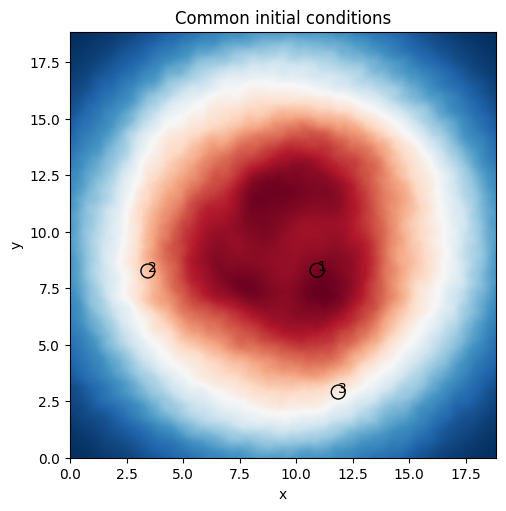

In [4]:
# State coordinates are packed as [all x, all y].
x0, y0 = initial_configuration.positions(initial_configuration.initial_state)
print("Trajectory       x0               y0")
for i, (x, y) in enumerate(zip(x0, y0), 1):
    print(f"{i:10d} {x:16.9f} {y:16.9f}")
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
grid = potential.grid
ax.imshow(np.asarray(potential.evaluate_grid(t_span[0])).T, origin="lower",
          extent=(grid.xmin, grid.xmin + grid.period, grid.ymin, grid.ymin + grid.period),
          cmap="RdBu_r")
ax.scatter(x0, y0, facecolors="none", edgecolors="black", s=100)
for i, (x, y) in enumerate(zip(x0, y0), 1):
    ax.annotate(str(i), (x, y))
ax.set(xlabel="x", ylabel="y", title="Common initial conditions")
plt.show()


## Generate one reference and run the nested sweep
Reference data and its audit are persisted with a unique run version. The full sweep can take time: all particles advance together, with every method using the same physical inputs and saved times. Outputs below are computed, never preset.

In [5]:
reference_result = run_high_precision_reference_trajectory(
    potential, initial_configuration, notebook_path=notebook_path,
    config=reference_config, potential_metadata=potential_metadata,
    initial_condition_metadata=initial_metadata, reference_name="step_ratio_abba4_bm4",
    version=datetime.now(timezone.utc).strftime("v%Y%m%d%H%M%S%f"),
    project_root=project_root,
)
result = run_implicit_method_accuracy_study(
    potential, initial_configuration, reference_result.trajectory,
    config=config, potential_metadata=potential_metadata,
    initial_condition_metadata=initial_metadata,
)
variants = {
    "ABBA4ImplicitSingleProjection": "ABBA4: single projection (primary)",
    "ABBA4Implicit": "ABBA4: three projections",
}
selected_names = ("BM4Implicit", *variants)
summaries = tuple(r for r in result.summaries() if r.method_name in selected_names)
for name in selected_names:
    for h in integration_steps:
        sol = result.solutions[name][h]
        assert sol.diagnostics["step_count"] == config.step_count(h)
        assert sol.diagnostics["nonlinear_solver"] == "newton"
        np.testing.assert_array_equal(sol.t, result.times)
        if name == "ABBA4ImplicitSingleProjection":
            assert sol.diagnostics["projection_placement"] == "around_complete_composition"
        if name == "BM4Implicit":
            assert sol.diagnostics["projection_solver_formulation"] == "bm4_implicit_reduced"
assert all(r.maximum_residual_to_tolerance <= 1.0 for r in summaries)
print(f"DOP853/Radau RMS discrepancy: {result.reference_floor:.6e}")
print(f"Ratio interpolation requires errors > {reference_floor_factor * result.reference_floor:.6e}")


DOP853/Radau RMS discrepancy: 1.880147e-06
Ratio interpolation requires errors > 1.880147e-05


Method,Step,Space-time RMS error,Final RMS error,Error / reference floor,Newton corrections,Max residual / tolerance
Implicit ABBA4 (three projections),0.1,5.43872e-01,1.17232e+00,289271.22,990,0.967
Implicit ABBA4 (single projection),0.1,1.81088e-01,1.27707e-01,96316.04,315,0.994
Implicit BM4,0.1,1.40320e-02,4.13063e-02,7463.25,208,0.814
Implicit ABBA4 (three projections),0.05,1.19522e-01,1.86285e-01,63570.79,1749,0.902
Implicit ABBA4 (single projection),0.05,1.19244e-01,2.01463e-01,63422.90,449,0.969
Implicit BM4,0.05,2.31585e-03,7.09202e-03,1231.74,397,0.957
Implicit ABBA4 (three projections),0.025,6.33436e-02,1.65094e-01,33690.80,2509,0.999
Implicit ABBA4 (single projection),0.025,6.11853e-02,1.60637e-01,32542.85,800,0.002
Implicit BM4,0.025,5.39914e-05,1.84085e-04,28.72,437,0.953
Implicit ABBA4 (three projections),0.0125,1.22241e-03,3.14745e-03,650.17,4800,0.036


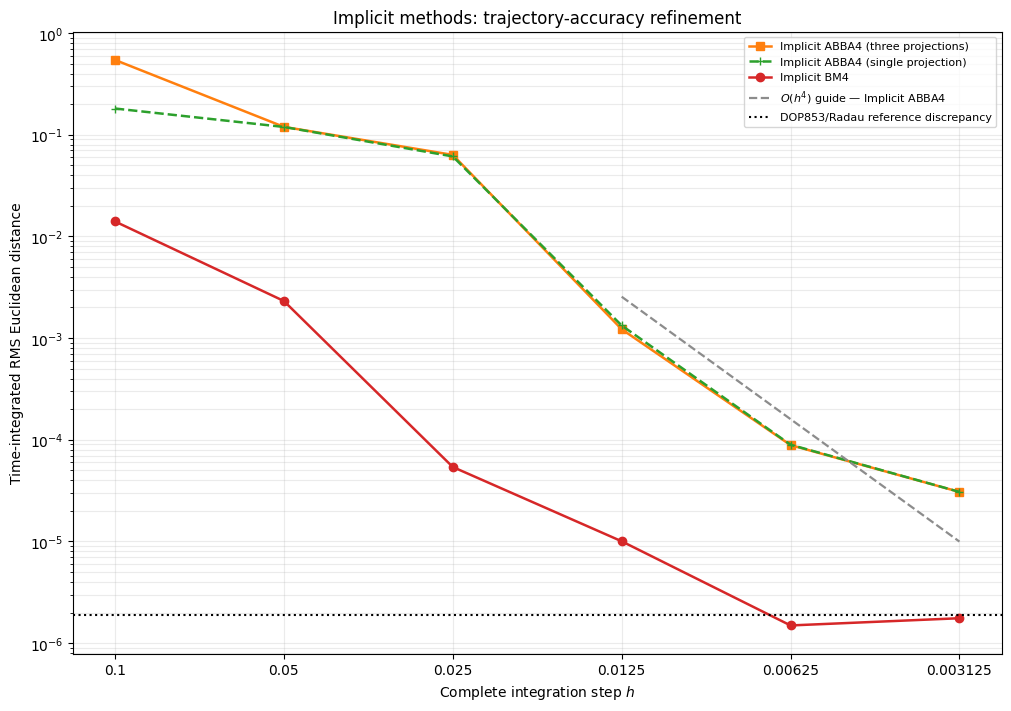

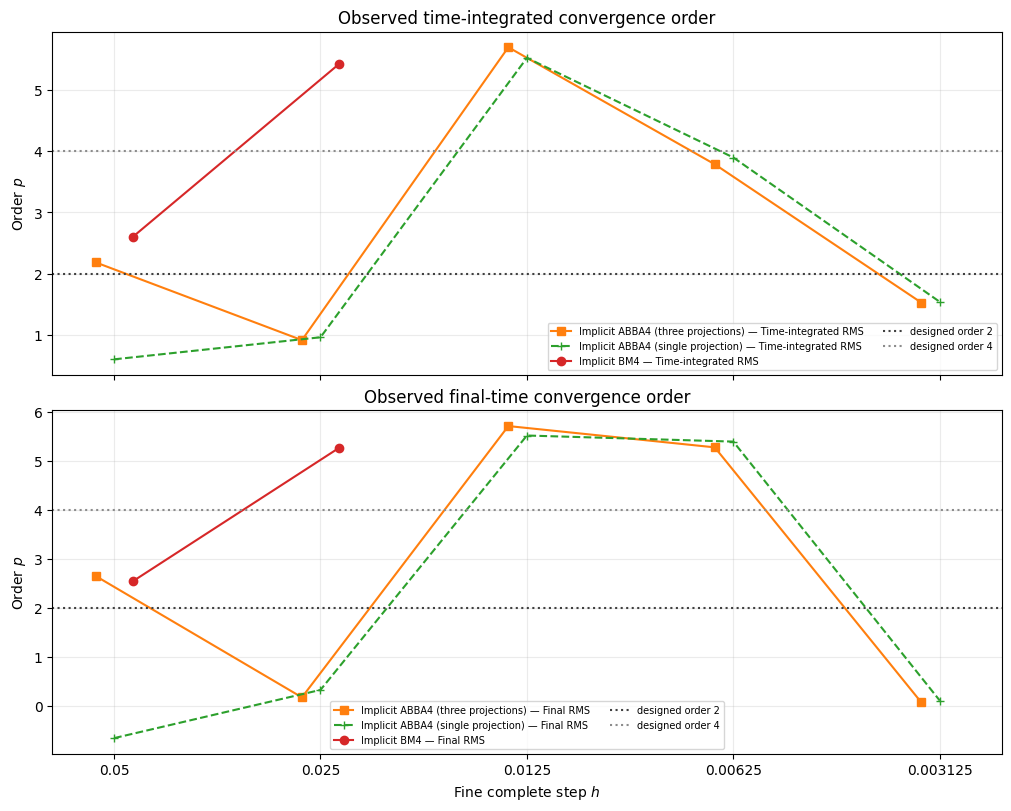

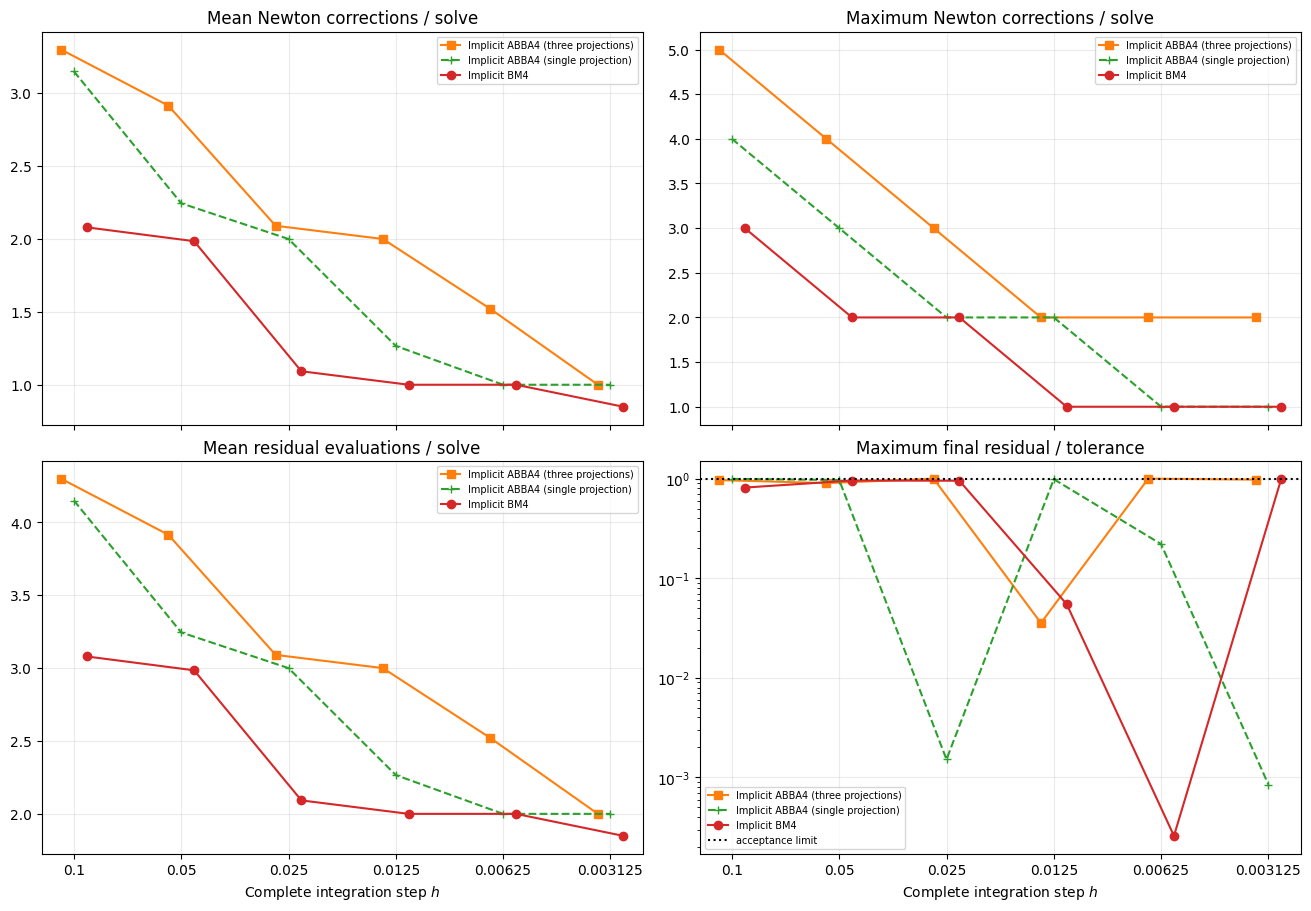

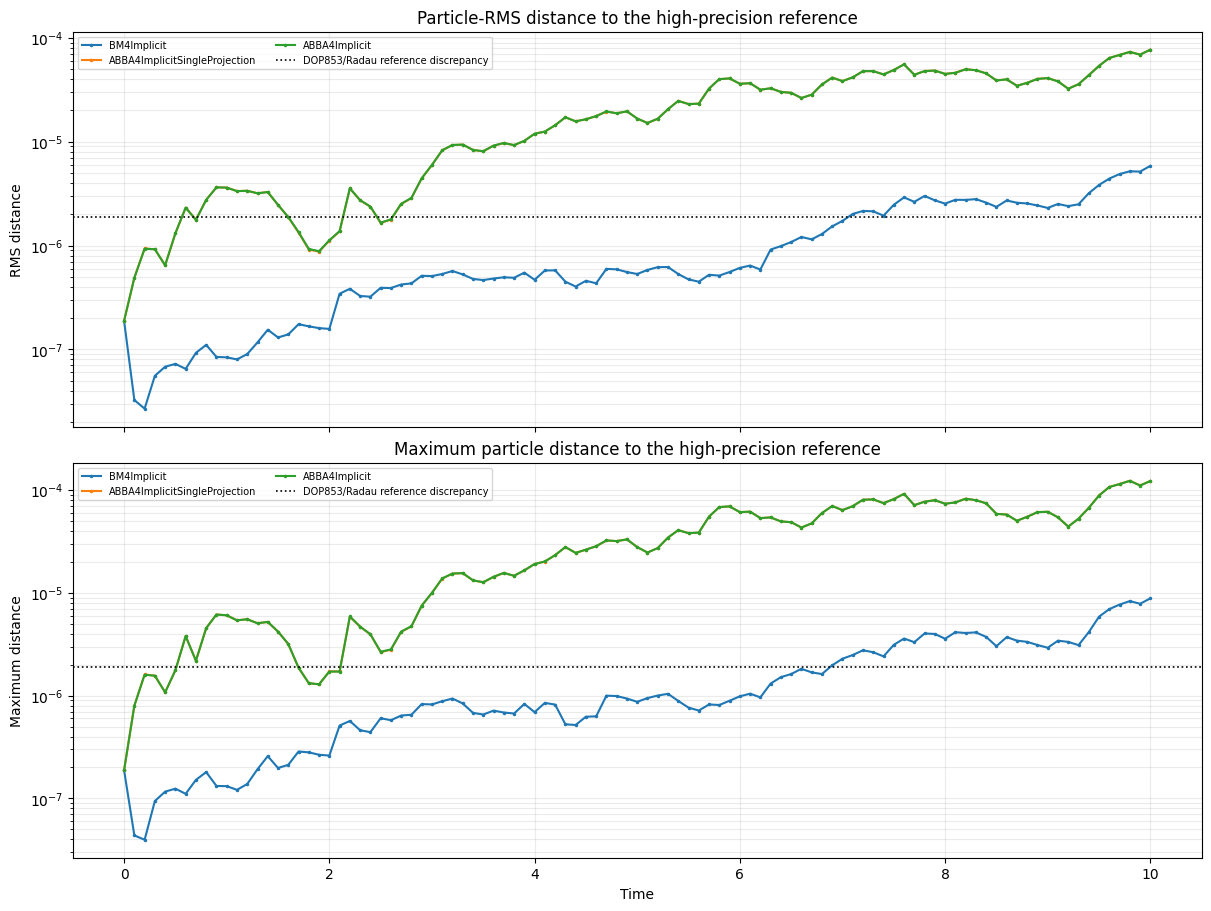

In [6]:
display_records_table(summaries, columns=(
    ("method_label", "Method", None), ("integration_step", "Step", ".6g"),
    ("time_integrated_rms_distance", "Space-time RMS error", ".5e"),
    ("final_rms_distance", "Final RMS error", ".5e"),
    ("reference_floor_ratio", "Error / reference floor", ".2f"),
    ("total_iterations", "Newton corrections", "d"),
    ("maximum_residual_to_tolerance", "Max residual / tolerance", ".3f"),
))
plot_implicit_method_accuracy_refinement(summaries, reference_floor=result.reference_floor)
plt.show()
orders = tuple(r for r in result.convergence_orders() if r.method_name in selected_names)
plot_implicit_method_observed_orders(orders)
plt.show()
plot_implicit_method_newton_refinement(summaries)
plt.show()
plot_trajectory_accuracy_over_time(
    result.times, {name: result.finest_series[name] for name in selected_names},
    reference_floor=result.reference_floor,
)
plt.show()


## Equivalent steps and the requested ratio
Invert each error curve locally in logarithmic coordinates and evaluate both at the **same target error**. Only adjacent, increasing, resolved error brackets are eligible. No extrapolation is performed; ambiguous branches are omitted. Reported local orders help identify whether fourth-order behavior is actually present.

If both methods satisfy $E\approx C h^4$, then
$$\boxed{\frac{h_{\mathrm{ABBA4}}}{h_{\mathrm{BM4}}}\approx\left(\frac{C_{\mathrm{BM4}}}{C_{\mathrm{ABBA4}}}\right)^{1/4}}.$$
The computation below does not impose order four: it uses measured local slopes. These are interpolated estimates, not new integrations at the predicted steps. Validate a chosen pair with fresh integrations before using it in a production run. A larger ratio does not by itself imply a faster method.

### ABBA4: single projection (primary)

Target RMS error,step_abba4,step_bm4,step_abba4 / step_bm4,ABBA4 local order,BM4 local order
5.39914e-05,0.004506,0.025,0.18024,1.541,5.423
1.08187e-04,0.00656378,0.0284187,0.23097,3.896,5.423
2.16782e-04,0.00784554,0.0323049,0.24286,3.896,5.423
4.34383e-04,0.00937761,0.0367226,0.25536,3.896,5.423
8.70407e-04,0.0112089,0.0417443,0.26851,3.896,5.423
1.74410e-03,0.0131269,0.0474528,0.27663,5.522,5.423
3.49479e-03,0.0148874,0.0585772,0.25415,5.522,2.599
7.00278e-03,0.0168841,0.0765357,0.22060,5.522,2.599
1.40320e-02,0.0191486,0.1,0.19149,5.522,2.599


### ABBA4: three projections

Target RMS error,step_abba4,step_bm4,step_abba4 / step_bm4,ABBA4 local order,BM4 local order
5.39914e-05,0.00452026,0.025,0.18081,1.530,5.423
1.08187e-04,0.00658796,0.0284187,0.23182,3.786,5.423
2.16782e-04,0.0079156,0.0323049,0.24503,3.786,5.423
4.34383e-04,0.00951079,0.0367226,0.25899,3.786,5.423
8.70407e-04,0.0114274,0.0417443,0.27375,3.786,5.423
1.74410e-03,0.0133049,0.0474528,0.28038,5.695,5.423
3.49479e-03,0.0150318,0.0585772,0.25661,5.695,2.599
7.00278e-03,0.0169828,0.0765357,0.22189,5.695,2.599
1.40320e-02,0.019187,0.1,0.19187,5.695,2.599


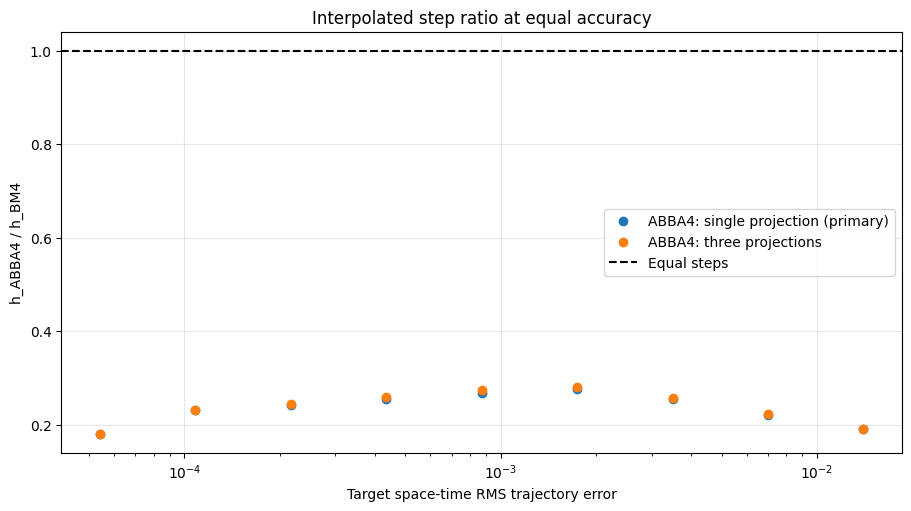

In [7]:
by_method = {name: {r.integration_step: r for r in summaries if r.method_name == name}
             for name in selected_names}
bm_errors = [by_method["BM4Implicit"][h].time_integrated_rms_distance for h in integration_steps]
ratios = {}
for name, label in variants.items():
    ab_errors = [by_method[name][h].time_integrated_rms_distance for h in integration_steps]
    rows = equal_accuracy_steps(
        integration_steps, bm_errors, ab_errors, reference_floor=result.reference_floor,
        floor_factor=reference_floor_factor, targets=target_errors, target_count=target_count,
    )
    ratios[label] = rows
    display(Markdown(f"### {label}"))
    if not rows:
        print("No resolved common error bracket. Extend the step range or tighten the reference/Newton tolerances.")
        continue
    display_records_table(rows, columns=(
        ("target_error", "Target RMS error", ".5e"),
        ("abba4_step", "step_abba4", ".6g"), ("bm4_step", "step_bm4", ".6g"),
        ("step_ratio", "step_abba4 / step_bm4", ".5f"),
        ("abba4_local_order", "ABBA4 local order", ".3f"),
        ("bm4_local_order", "BM4 local order", ".3f"),
    ))
    if target_errors is not None:
        omitted = [v for v in target_errors if not any(np.isclose(v, r.target_error, rtol=1e-12, atol=0) for r in rows)]
        print(f"Unsupported targets: {omitted}")
plot_equal_accuracy_steps(ratios)
plt.show()


In [8]:
for label, rows in ratios.items():
    if not rows:
        continue
    values = np.asarray([r.step_ratio for r in rows])
    print(f"{label}: step_abba4 / step_bm4 ranges from {values.min():.5g} to {values.max():.5g} "
          f"over target errors [{min(r.target_error for r in rows):.3e}, {max(r.target_error for r in rows):.3e}].")
    print("Use the row nearest your required accuracy; h_ABBA4 = ratio * h_BM4.")
    if any(abs(r.abba4_local_order - 4) > 0.5 or abs(r.bm4_local_order - 4) > 0.5 for r in rows):
        print("Some local orders differ substantially from four: do not summarize this sweep with a universal fourth-order ratio.")


ABBA4: single projection (primary): step_abba4 / step_bm4 ranges from 0.18024 to 0.27663 over target errors [5.399e-05, 1.403e-02].
Use the row nearest your required accuracy; h_ABBA4 = ratio * h_BM4.
Some local orders differ substantially from four: do not summarize this sweep with a universal fourth-order ratio.
ABBA4: three projections: step_abba4 / step_bm4 ranges from 0.18081 to 0.28038 over target errors [5.399e-05, 1.403e-02].
Use the row nearest your required accuracy; h_ABBA4 = ratio * h_BM4.
Some local orders differ substantially from four: do not summarize this sweep with a universal fourth-order ratio.
